In [12]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


from xgboost import XGBClassifier
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [13]:
SEASON_MAP = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}

TIME_BINS = [-1, 5, 9, 14, 19, 24]
TIME_LABELS = ["Night", "Morning_Rush", "Day", "Afternoon_Rush", "Evening"]

AGE_MAP = {
    "0 to 4": "Child",
    "5 to 9": "Child",
    "10 to 14": "Child",
    "15 to 19": "Young_Adult",
    "20 to 24": "Young_Adult",
    "25 to 29": "Adult",
    "30 to 34": "Adult",
    "35 to 39": "Adult",
    "40 to 44": "Adult",
    "45 to 49": "Adult",
    "50 to 54": "Adult",
    "55 to 59": "Adult",
    "60 to 64": "Adult",
    "65 to 69": "Senior",
    "70 to 74": "Senior",
    "75 to 79": "Senior",
    "80 to 84": "Senior",
    "85 to 89": "Senior",
    "90 to 94": "Senior",
    "Over 95": "Senior",
    "unknown": "Unknown",
    "Unknown": "Unknown",
}

PEDCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Ability Impaired, Alcohol Over .80": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

DRIVCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Alcohol Over .08": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

PEDACT_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Crossing with right of way": "crossing",
    "Crossing, no Traffic Control": "crossing",
    "Crossing without right of way": "crossing",
    "Crossing, Pedestrian Crossover": "crossing",
    "Crossing marked crosswalk without ROW": "crossing",
    "Walking on Roadway with Traffic": "walking_roadway",
    "Walking on Roadway Against Traffic": "walking_roadway",
    "Running onto Roadway": "sudden_entry",
    "Coming From Behind Parked Vehicle": "sudden_entry",
    "On Sidewalk or Shoulder": "sidewalk_shoulder",
    "Person Getting on/off Vehicle": "vehicle_related",
    "Person Getting on/off School Bus": "vehicle_related",
    "Pushing/Working on Vehicle": "vehicle_related",
    "Playing or Working on Highway": "other",
    "Other": "other",
}

PEDESTRIAN_GROUPED_MAPPING = {
    "Pedestrian hit at mid-block": "mid_block",
    "Vehicle hits the pedestrian walking or running out from between parked vehicles at mid-block": "mid_block",
    "Pedestrian hit a PXO/ped. Mid-block signal": "mid_block",
    "Vehicle turns left while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns left while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle is going straight thru inter.while ped cross with ROW": "intersection_straight",
    "Vehicle is going straight thru inter.while ped cross without ROW": "intersection_straight",
    "Pedestrian hit on sidewalk or shoulder": "sidewalk_shoulder",
    "Pedestrian hit at private driveway": "private_property",
    "Pedestrian hit at parking lot": "private_property",
    "Vehicle is reversing and hits pedestrian": "reversing",
    "Pedestrian involved in a collision with transit vehicle anywhere along roadway": "transit_collision",
    "Unknown": "unknown",
    "Other / Undefined": "other",
}

CYCLISTYPE_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Insufficient information (to determine cyclist crash type).": "unknown",
    "Motorist turned left across cyclists path.": "motorist_turn_conflict",
    "Motorist turns right at non-signal Inter.(stop, yield, no cont.,and dwy) and strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on green or amber at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on red at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist makes u-turn in-front of cyclist.": "motorist_turn_conflict",
    "Cyclist turned left across motorists path.": "cyclist_turn_conflict",
    "Cyclist turns right across motorists path": "cyclist_turn_conflict",
    "Cyclist makes u-turn in-front of driver.": "cyclist_turn_conflict",
    "Cyclist without ROW rides into path of motorist at inter, lnwy, dwy-Cyclist not turn.": "row_violation",
    "Motorist without ROW drives into path of cyclist at inter, lnwy, dwy-Driver not turn.": "row_violation",
    "Cyclist and Driver travelling in same direction. One vehicle sideswipes the other.": "same_direction_collision",
    "Cyclist and Driver travelling in same direction. One vehicle rear-ended the other.": "same_direction_collision",
    "Cyclist struck opened vehicle door": "dooring",
    "Cyclist loses control and strikes object (pole, ttc track)": "cyclist_loss_control",
    "Cyclist falls off bike - no contact with motorist.": "cyclist_loss_control",
    "Cyclist strikes a parked vehicle.": "cyclist_loss_control",
    "Cyclist rode off sidewalk into road at midblock.": "midblock_entry",
    "Motorist reversing struck cyclist.": "reversing_collision",
    "Motorist loses control and strikes cyclist.": "reversing_collision",
    "Cyclist strikes pedestrian.": "pedestrian_conflict",
    "Cyclist struck at PXO(cyclist either travel in same dir. as veh. or ride across xwalk)": "crossing_facility",
}

ROW_DROP_COLUMNS = [
    "OBJECTID",
    "INDEX",
    "STREET1",
    "STREET2",
    "OFFSET",
    "LATITUDE",
    "LONGITUDE",
    "INJURY",
    "FATAL_NO",
    "VEHTYPE",
    "HOOD_158",
    "HOOD_140",
    "NEIGHBOURHOOD_140",
    "DIVISION",
    "x",
    "y",
    "NEIGHBOURHOOD_158",
]

GROUPED_COLUMNS_TO_DROP = ["PEDCOND", "DRIVCOND", "PEDACT", "PEDTYPE", "CYCLISTYPE"]

In [14]:
def _build_accident_split(data, test_size=0.2, random_state=42):
    accident_labels = (
        data.assign(FATAL_ACCIDENT=(data["ACCLASS"] == "Fatal").astype(int))
        .groupby("ACCNUM", as_index=False)["FATAL_ACCIDENT"]
        .max()
    )
    train_ids, test_ids = train_test_split(
        accident_labels["ACCNUM"],
        test_size=test_size,
        random_state=random_state,
        stratify=accident_labels["FATAL_ACCIDENT"],
    )
    return set(train_ids), set(test_ids)


def _fill_missing_values(X_train, X_test):
    fill_values = {}
    for column in X_train.columns:
        if not X_train[column].isnull().any():
            continue
        if pd.api.types.is_numeric_dtype(X_train[column]):
            fill_values[column] = X_train[column].median()
        else:
            unique_values = set(X_train[column].dropna().astype(str).unique())
            fill_values[column] = "No" if "Yes" in unique_values else "Unknown"
    X_train = X_train.fillna(fill_values)
    X_test = X_test.fillna(fill_values)
    return X_train, X_test


def _add_time_features(frame):
    frame = frame.copy()
    frame["DATE"] = pd.to_datetime(frame["DATE"])
    frame["TIME"] = pd.to_numeric(frame["TIME"], errors="coerce").fillna(0)
    frame["HOUR"] = frame["TIME"] // 100
    frame["SEASON"] = frame["DATE"].dt.month.map(SEASON_MAP)
    frame["IS_WEEKEND"] = frame["DATE"].dt.dayofweek.apply(lambda value: 1 if value >= 5 else 0)
    frame["TIME_RANGE"] = pd.cut(frame["HOUR"], bins=TIME_BINS, labels=TIME_LABELS)
    frame["AGE_GROUP"] = frame["INVAGE"].map(AGE_MAP).fillna("Unknown")
    return frame


def _add_grouped_columns(frame):
    frame = frame.copy()
    frame["PEDCOND_GRP"] = frame["PEDCOND"].map(PEDCOND_GROUPED_MAPPING).fillna("other")
    frame["DRIVCOND_GRP"] = frame["DRIVCOND"].map(DRIVCOND_GROUPED_MAPPING).fillna("other")
    frame["PEDACT_GRP"] = frame["PEDACT"].map(PEDACT_GROUPED_MAPPING).fillna("other")
    frame["PEDTYPE_GRP"] = frame["PEDTYPE"].map(PEDESTRIAN_GROUPED_MAPPING).fillna("other")
    frame["CYCLISTYPE_GRP"] = frame["CYCLISTYPE"].map(CYCLISTYPE_GROUPED_MAPPING).fillna("other")
    return frame


def _preprocess_rows(X_train, X_test):
    X_train = X_train.fillna('Unknown')
    X_test = X_test.fillna('Unknown')

    for frame in [X_train, X_test]:
        cat_cols = frame.select_dtypes(include=['object']).columns
        for col in cat_cols:
            frame[col] = frame[col].astype(str).str.strip()

    X_train = _add_time_features(X_train)
    X_test = _add_time_features(X_test)
    
    for frame in [X_train, X_test]:
        frame['hour_sin'] = np.sin(2 * np.pi * frame['HOUR'] / 24.0)
        frame['hour_cos'] = np.cos(2 * np.pi * frame['HOUR'] / 24.0)

    X_train = _add_grouped_columns(X_train)
    X_test = _add_grouped_columns(X_test)

    # Удаляем старые колонки времени и возраста
    cols_to_drop = ["DATE", "TIME", "HOUR", "INVAGE"] + GROUPED_COLUMNS_TO_DROP
    X_train = X_train.drop(columns=cols_to_drop)
    X_test = X_test.drop(columns=cols_to_drop)

    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, drop_first=True)

    cols_to_remove = [c for c in X_train_encoded.columns if '_Unknown' in c or '_nan' in c or '_unknown' in c]
    X_train_encoded.drop(columns=cols_to_remove, inplace=True, errors='ignore')
    X_test_encoded.drop(columns=cols_to_remove, inplace=True, errors='ignore')

    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)
    return X_train_encoded.fillna(0), X_test_encoded.fillna(0)


def _aggregate_accident_features(X_encoded, accident_ids):
    temp_df = X_encoded.copy()
    temp_df["ACCNUM"] = accident_ids.values
    
    all_cols = [c for c in X_encoded.columns if c != "ACCNUM"]
    
    columns_to_sum = [col for col in all_cols if any(prefix in col for prefix in 
                     ['INVTYPE_', 'DRIVACT_', 'CYCACT_', 'PEDACT_', 'DRIVCOND_', 'PEDCOND_', 
                      'MANOEUVER_', 'IMPACTYPE_', 'CYCCOND_'])]
    
    columns_to_max = [col for col in all_cols if col not in columns_to_sum]
    
    agg_funcs = {col: 'sum' for col in columns_to_sum}
    agg_funcs.update({col: 'max' for col in columns_to_max})
    
    accident_features = temp_df.groupby("ACCNUM").agg(agg_funcs)
    
    participant_count = accident_ids.value_counts().rename("PARTICIPANT_COUNT")
    accident_features["PARTICIPANT_COUNT"] = participant_count.reindex(accident_features.index).fillna(0)
    
    return accident_features.sort_index()



def _aggregate_accident_target(y_rows, accident_ids):
    accident_target = (
        pd.DataFrame({"ACCNUM": accident_ids.values, "FATAL_ACCIDENT": (y_rows == "Fatal").astype(int).values})
        .groupby("ACCNUM", as_index=True)["FATAL_ACCIDENT"]
        .max()
        .sort_index()
    )
    return accident_target


def prepare_accident_level_data(csv_path="TOTAL_KSI_3737821728629277523.csv", test_size=0.2, random_state=42):
    data = pd.read_csv(csv_path)
    data = data[data["ACCNUM"].notna() & data["ACCLASS"].notna()].copy()

    train_accidents, test_accidents = _build_accident_split(
        data,
        test_size=test_size,
        random_state=random_state,
    )

    train_rows = data[data["ACCNUM"].isin(train_accidents)].copy()
    test_rows = data[data["ACCNUM"].isin(test_accidents)].copy()

    train_accnum = train_rows["ACCNUM"].copy()
    test_accnum = test_rows["ACCNUM"].copy()

    data_new_train = train_rows.drop(columns=ROW_DROP_COLUMNS)
    data_new_test = test_rows.drop(columns=ROW_DROP_COLUMNS)

    X_train_rows = data_new_train.drop(columns=["ACCLASS", "ACCNUM"])
    X_test_rows = data_new_test.drop(columns=["ACCLASS", "ACCNUM"])
    y_train_rows = train_rows["ACCLASS"]
    y_test_rows = test_rows["ACCLASS"]

    X_train_encoded, X_test_encoded = _preprocess_rows(X_train_rows, X_test_rows)

    X_train_accident = _aggregate_accident_features(X_train_encoded, train_accnum)
    X_test_accident = _aggregate_accident_features(X_test_encoded, test_accnum)
    y_train_accident = _aggregate_accident_target(y_train_rows, train_accnum)
    y_test_accident = _aggregate_accident_target(y_test_rows, test_accnum)

    X_train_accident, X_test_accident = X_train_accident.align(
        X_test_accident,
        join="left",
        axis=1,
        fill_value=0,
    )
    y_test_accident = y_test_accident.reindex(X_test_accident.index)
    y_train_accident = y_train_accident.reindex(X_train_accident.index)

    scaler = StandardScaler()

    X_train_acc_scaled = scaler.fit_transform(X_train_accident)
    X_test_acc_scaled = scaler.transform(X_test_accident)

    # Чтобы сохранить имена колонок (StandardScaler возвращает numpy array), 
    # можно обернуть обратно в DataFrame, если хочешь видеть графики потом
    X_train_final = pd.DataFrame(X_train_acc_scaled, columns=X_train_accident.columns, index=X_train_accident.index)
    X_test_final = pd.DataFrame(X_test_acc_scaled, columns=X_test_accident.columns, index=X_test_accident.index)

    return X_train_final, X_test_final, y_train_accident.astype(int), y_test_accident.astype(int)

if __name__ == "__main__":
    X_train_acc, X_test_acc, y_train_acc, y_test_acc = prepare_accident_level_data()
    
    for df in [X_train_acc, X_test_acc]:
        df['VULNERABILITY_SENIOR_PED'] = df['AGE_GROUP_Senior'] * df['PEDESTRIAN_Yes']
        df['BLIND_SPOT_CRASH'] = df['PEDTYPE_GRP_private_property'] * df['MANOEUVER_Overtaking']
        df['TRUCK_EXCEEDS_LIMIT'] = df['DRIVACT_Exceeding Speed Limit'] * df['INVTYPE_Truck Driver']
        df['FATAL_COMBO_RAIN_SPEED'] = df['VISIBILITY_Rain'] * df['DRIVACT_Speed too Fast For Condition']
    
    
    X_train_final = X_train_acc.astype("float32")
    y_train_final = y_train_acc.astype("float32")
    X_test_final = X_test_acc.astype("float32")
    y_test_final = y_test_acc.astype("float32")

    print(X_train_final.shape[0])


3963


In [15]:
# optimal threshold finder (f1-based)

def find_best_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    return best_threshold, precisions[best_idx], recalls[best_idx], f1_scores[best_idx]

In [16]:
# NN TRAINING

model_top = Sequential([
    Input(shape=(X_train_final.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model_top.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

class_weight = {0: 1, 1: 6} 

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history_top = model_top.fit(
    X_train_final, y_train_final,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    class_weight={0: 1, 1: 6},
    callbacks=[early_stop],
    verbose=1
)

# TEST

y_pred_probs_top = model_top.predict(X_test_final)
thr_nn, p_nn, r_nn, f1_nn = find_best_threshold(y_test_final, y_pred_probs_top)
y_pred_top = (y_pred_probs_top > thr_nn).astype(int)

print(confusion_matrix(y_test_final, y_pred_top))
print(classification_report(y_test_final, y_pred_top, target_names=['Non-Fatal (0)', 'Fatal (1)']))

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.5624 - loss: 1.4068 - val_AUC: 0.5837 - val_loss: 0.7455
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6727 - loss: 1.0727 - val_AUC: 0.6144 - val_loss: 0.7557
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7367 - loss: 0.9962 - val_AUC: 0.6090 - val_loss: 0.7341
Epoch 4/100
 1/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.6394 - loss: 1.2894

/Users/sofiabalaba/miniforge3/envs/ML_project/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7624 - loss: 0.9547 - val_AUC: 0.6215 - val_loss: 0.7310
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7999 - loss: 0.8884 - val_AUC: 0.6236 - val_loss: 0.6931
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8351 - loss: 0.8253 - val_AUC: 0.6314 - val_loss: 0.6738
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8412 - loss: 0.8079 - val_AUC: 0.6361 - val_loss: 0.6617
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8579 - loss: 0.7636 - val_AUC: 0.6340 - val_loss: 0.6735
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8644 - loss: 0.7488 - val_AUC: 0.6338 - val_loss: 0.6719
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8716 - loss: 0.7265 - val_AUC: 0.6216 - val_loss: 0.6734
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8870 - loss: 0.6876 - val_AUC: 0.6243 - val_loss: 0.6601
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8906 - loss: 

In [17]:
# Log reg model

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_final, y_train_final)

y_probs_lr = log_reg.predict_proba(X_test_final)[:, 1]
thr_lr, p_lr, r_lr, f1_lr = find_best_threshold(y_test_final, y_probs_lr)
y_pred_lr = (y_probs_lr > thr_lr).astype(int)

print("Logistic Regression")
print(confusion_matrix(y_test_final, y_pred_lr))
print(classification_report(y_test_final, y_pred_lr))

Logistic Regression
[[712 154]
 [ 65  60]]
              precision    recall  f1-score   support

         0.0       0.92      0.82      0.87       866
         1.0       0.28      0.48      0.35       125

    accuracy                           0.78       991
   macro avg       0.60      0.65      0.61       991
weighted avg       0.84      0.78      0.80       991



In [18]:
# random forest model

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train_final)

y_probs_rf = rf_model.predict_proba(X_test_final)[:, 1]
thr_rf, p_rf, r_rf, f1_rf = find_best_threshold(y_test_final, y_probs_rf)
y_pred_rf = (y_probs_rf > thr_rf).astype(int)

print("Random Forest")
print(confusion_matrix(y_test_final, y_pred_rf))
print(classification_report(y_test_final, y_pred_rf))

Random Forest
[[763 103]
 [ 77  48]]
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89       866
         1.0       0.32      0.38      0.35       125

    accuracy                           0.82       991
   macro avg       0.61      0.63      0.62       991
weighted avg       0.83      0.82      0.83       991



In [19]:
# Grad boosting model

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_final, y_train_final)

y_probs_gb = gb_model.predict_proba(X_test_final)[:, 1]
thr_gb, p_gb, r_gb, f1_gb = find_best_threshold(y_test_final, y_probs_gb)
y_pred_gb = (y_probs_gb > thr_gb).astype(int)

print("Gradient Boosting")
print(confusion_matrix(y_test_final, y_pred_gb))
print(classification_report(y_test_final, y_pred_gb))

Gradient Boosting
[[715 151]
 [ 65  60]]
              precision    recall  f1-score   support

         0.0       0.92      0.83      0.87       866
         1.0       0.28      0.48      0.36       125

    accuracy                           0.78       991
   macro avg       0.60      0.65      0.61       991
weighted avg       0.84      0.78      0.80       991



In [20]:
# models evaluation

def evaluate_model(name, y_true, y_pred):
    return [
        name,
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

models = {
    "NN": y_pred_top,
    "LogReg": y_pred_lr,
    "RandomForest": y_pred_rf,
    "GradBoost": y_pred_gb
}

results = []

for name, preds in models.items():
    results.append(evaluate_model(name, y_test_final, preds))

df = pd.DataFrame(results, columns=["Model", "Precision", "Recall", "F1"])
print(df)

          Model  Precision  Recall        F1
0            NN   0.222571   0.568  0.319820
1        LogReg   0.280374   0.480  0.353982
2  RandomForest   0.317881   0.384  0.347826
3     GradBoost   0.284360   0.480  0.357143


          Model  Precision  Recall        F1
0            NN   0.222571   0.568  0.319820
1        LogReg   0.280374   0.480  0.353982
2  RandomForest   0.317881   0.384  0.347826
3     GradBoost   0.284360   0.480  0.357143


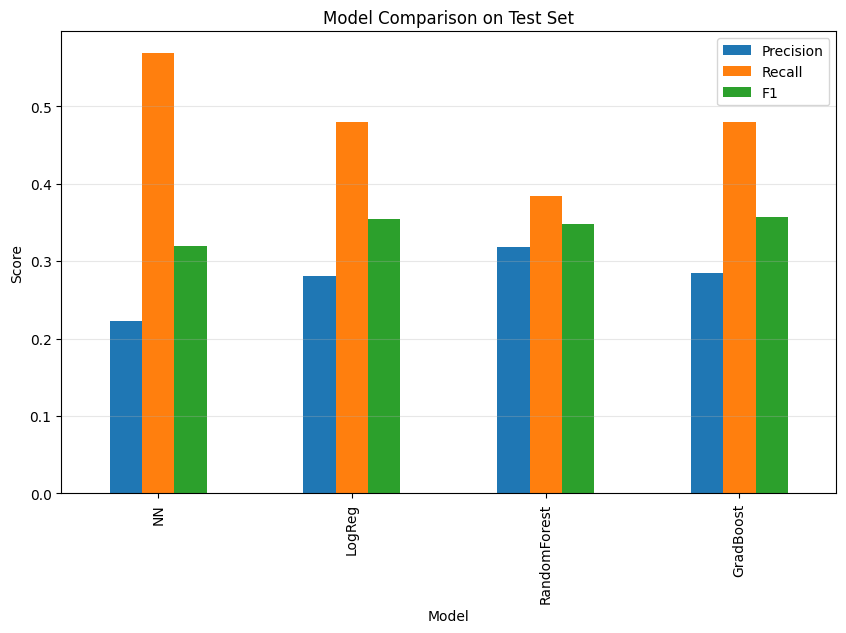

In [21]:
# models eval

models = {
    "NN": y_pred_top,
    "LogReg": y_pred_lr,
    "RandomForest": y_pred_rf,
    "GradBoost": y_pred_gb
}

results = []

for name, preds in models.items():
    results.append(evaluate_model(name, y_test_final, preds))

df = pd.DataFrame(results, columns=["Model", "Precision", "Recall", "F1"])
print(df)

df.set_index("Model")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison on Test Set")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

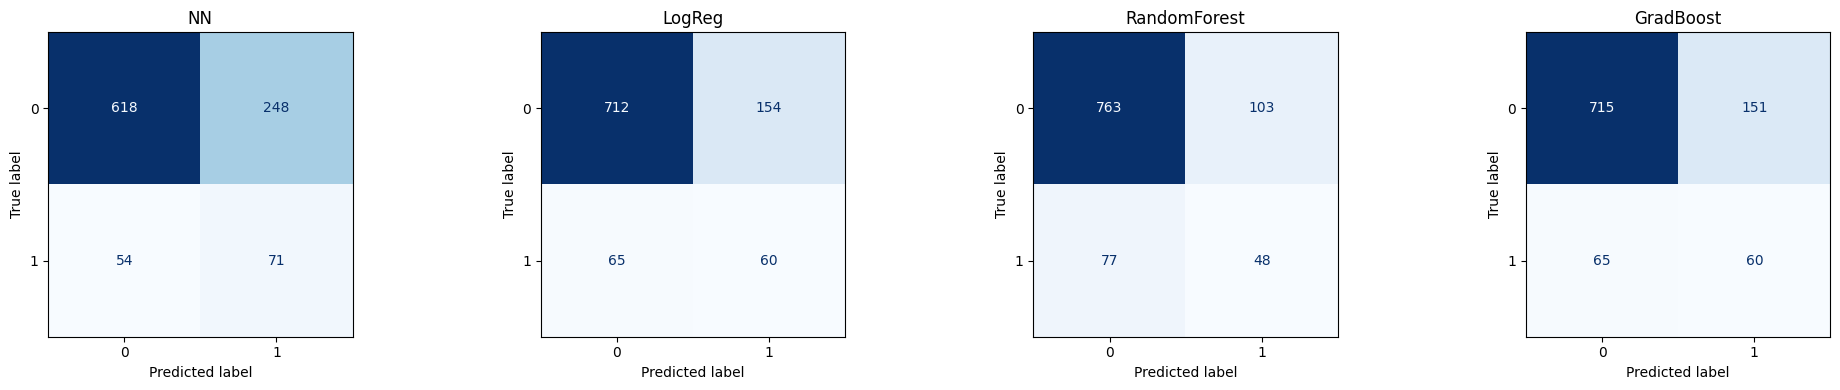

In [22]:
# confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(models_dict, y_true):
    n = len(models_dict)
    plt.figure(figsize=(5 * n, 4))

    for i, (name, y_pred) in enumerate(models_dict.items(), 1):
        cm = confusion_matrix(y_true, y_pred)

        plt.subplot(1, n, i)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(values_format='d', cmap='Blues', colorbar=False, ax=plt.gca())

        plt.title(name)

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(models, y_test_final)